In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# RFMC 분석

* **R (Recency,최신성)** : days_since_last
* **F (Frequency,빈도)** : visit_count, avg_revisit_days_imp
* **M (Monetary,금액)** : paidAmount
* **C (Centrality,중심성)** : pagerank, degree, closeness, betweenness, eigen

In [2]:
df = pd.read_csv("../data/feature통합.csv")
df.head()

,customerId,fullName,phoneNumber,dateOfBirth,isMarketingAgreed,storeId,visit_count,first_visit,last_visit,avg_revisit_days,pagerank,degree,betweenness,closeness,eigen,community,paidAmount,days_since_first,days_since_last,revisited
0,01H85T8BGM0WMY2H9G72XB1EX7,강*훈,************0485,2003-02-10,2025-01-27 09:53:31,3,5,2023-08-19 02:32:10.656565,2024-09-14 08:51:40.023686,98.065884,1.364909,4.0,6.0,1.0,0.012923,5982.0,20300.0,633,241,0
1,01H85T8BGM0WMY2H9G72XB1EX7,강*훈,************0485,2003-02-10,2025-01-27 09:53:31,5,1,2025-01-27 09:50:45.322711,2025-01-27 09:50:45.322711,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4500.0,106,106,0
2,01H85T8BGM0WMY2H9G72XB1EX7,강*훈,************0485,2003-02-10,2025-01-27 09:53:31,10028,1,2024-12-17 08:44:17.586781,2024-12-17 08:44:17.586781,NaN,0.961240,1.0,0.0,1.0,0.009745,3331.0,22204.0,147,147,0
3,01H9A0BE3PH0JVEEY4KDZT0Y5J,홍*걸,************9833,1988-05-12,2024-12-21 04:20:23,3,11,2023-09-02 03:52:45.381588,2025-03-15 03:44:27.335581,55.999424,0.961240,1.0,0.0,1.0,0.009046,4202.0,70950.0,619,59,1
4,01H9WS3AZE2XN9YPEQXYSM6PK9,정*서,************8873,2004-04-23,2024-09-15 05:10:58,3,5,2023-09-09 10:51:30.433531,2025-02-02 04:32:22.748740,127.934179,2.391401,6.0,26.0,1.0,0.023746,5471.0,42300.0,612,100,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729 entries, 0 to 728
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerId         729 non-null    object 
 1   fullName           728 non-null    object 
 2   phoneNumber        725 non-null    object 
 3   dateOfBirth        438 non-null    object 
 4   isMarketingAgreed  729 non-null    object 
 5   storeId            729 non-null    int64  
 6   visit_count        729 non-null    int64  
 7   first_visit        729 non-null    object 
 8   last_visit         729 non-null    object 
 9   avg_revisit_days   299 non-null    float64
 10  pagerank           436 non-null    float64
 11  degree             436 non-null    float64
 12  betweenness        436 non-null    float64
 13  closeness          436 non-null    float64
 14  eigen              436 non-null    float64
 15  community          436 non-null    float64
 16  paidAmount         723 non

In [4]:
df.isna().sum()

customerId             0
fullName               1
phoneNumber            4
dateOfBirth          291
isMarketingAgreed      0
storeId                0
visit_count            0
first_visit            0
last_visit             0
avg_revisit_days     430
pagerank             293
degree               293
betweenness          293
closeness            293
eigen                293
community            293
paidAmount             6
days_since_first       0
days_since_last        0
revisited              0
dtype: int64

In [5]:
df.dropna(subset=['phoneNumber']).isna().sum()

customerId             0
fullName               1
phoneNumber            0
dateOfBirth          287
isMarketingAgreed      0
storeId                0
visit_count            0
first_visit            0
last_visit             0
avg_revisit_days     429
pagerank             293
degree               293
betweenness          293
closeness            293
eigen                293
community            293
paidAmount             6
days_since_first       0
days_since_last        0
revisited              0
dtype: int64

In [6]:
df = df.dropna(subset=['phoneNumber'])

In [7]:
# df['paidAmount_log'] = np.log1p(df['paidAmount'])
# df['betweenness_log'] = np.log1p(df['betweenness'])

feat_cols = [
    'days_since_last',      # 마지막 방문 이후 경과
    'visit_count',          # 방문 횟수
    'avg_revisit_days_imp',     # 평균 재방문 간격
    'paidAmount',           # 총 결제액(혹은 평균 객단가)
    'pagerank', 'degree', 'closeness', 'betweenness', 'eigen'  # 그래프 지표
]

# 결측치 처리(간단히 평균 대체; 실제로는 0, 중앙값, 예측치 등 검토)
max_avg = df['avg_revisit_days'].max()
df['avg_revisit_days_imp'] = df['avg_revisit_days'].fillna(max_avg)
df['paidAmount']  = df['paidAmount'].fillna(0)
central_cols = ['pagerank','degree','closeness','betweenness','eigen']
df[central_cols] = df[central_cols].fillna(0)

In [8]:
df[feat_cols].isna().sum()

days_since_last         0
visit_count             0
avg_revisit_days_imp    0
paidAmount              0
pagerank                0
degree                  0
closeness               0
betweenness             0
eigen                   0
dtype: int64

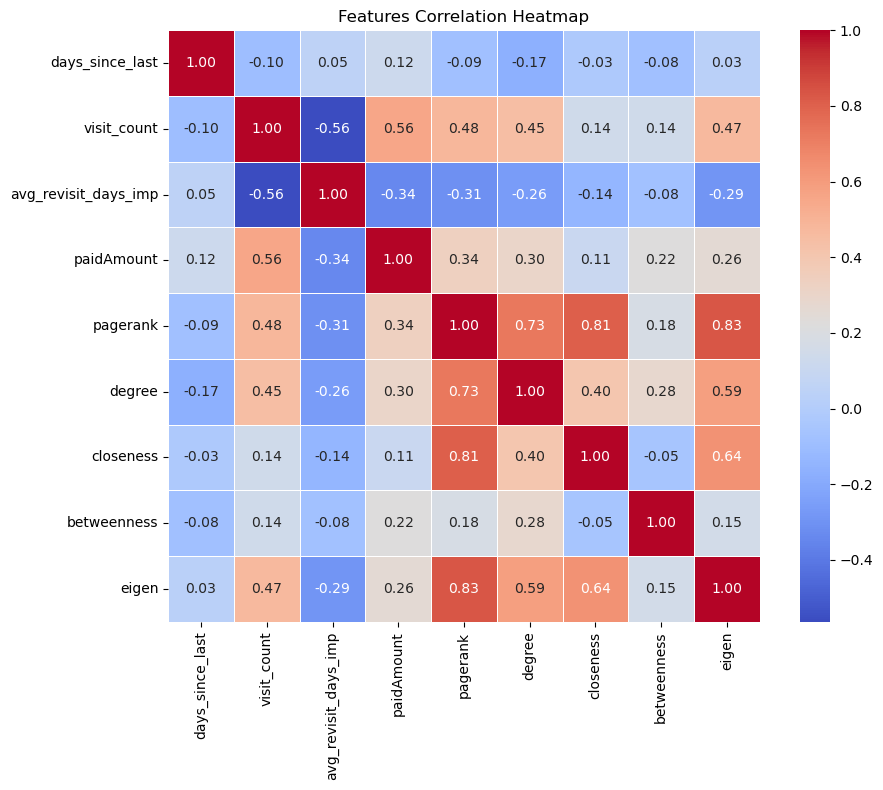

In [9]:
# corr: pandas.DataFrame, numeric_df.corr() 로 구한 상관계수 행렬
plt.figure(figsize=(10,8))
sns.heatmap(df[feat_cols].corr(), 
            annot=True,        # 셀 안에 값 표시
            fmt=".2f",         # 소수점 둘째 자리 포맷
            cmap="coolwarm",   # 컬러맵
            linewidths=0.5,    # 셀 경계 두께
            square=True)       # 정사각형 셀
plt.title("Features Correlation Heatmap")
plt.tight_layout()
plt.show()

In [10]:
df[feat_cols]

,days_since_last,visit_count,avg_revisit_days_imp,paidAmount,pagerank,degree,closeness,betweenness,eigen
0,241,5,98.065884,20300.0,1.364909,4.0,1.0,6.0,0.012923
1,106,1,420.918749,4500.0,0.000000,0.0,0.0,0.0,0.000000
2,147,1,420.918749,22204.0,0.961240,1.0,1.0,0.0,0.009745
3,59,11,55.999424,70950.0,0.961240,1.0,1.0,0.0,0.009046
4,100,5,127.934179,42300.0,2.391401,6.0,1.0,26.0,0.023746
...,...,...,...,...,...,...,...,...,...
724,1,1,420.918749,9900.0,0.961240,2.0,1.0,0.0,0.009046
725,1,1,420.918749,8500.0,0.961240,2.0,1.0,0.0,0.009046
726,1,4,10.989419,16500.0,0.961240,6.0,1.0,0.0,0.009046
727,0,1,420.918749,9900.0,0.961240,1.0,1.0,0.0,0.009046


In [11]:
import numpy as np
import pandas as pd

quartiledf = df.copy()

for col in feat_cols:
    # 매장(storeId)별로 퍼센타일 rank 계산 → 4점 척도로 변환
    quartiledf[f'{col}_Q'] = (
        quartiledf.groupby('storeId')[col]                      # ① 매장별로 묶고
                 .transform(lambda s:                           # ② 원래 index로 돌려놓으며
                            np.ceil(s.rank(method='first', pct=True) * 4)  # ③ 1~4점화
                            .astype(int)
                           )
                 .clip(1, 4)                                    # ④ 0 · 5 방지
    )

# 확인용 컬럼 정리
cols = [*feat_cols, *[f'{c}_Q' for c in feat_cols], 'storeId']
quartiledf[cols].head()

,days_since_last,visit_count,avg_revisit_days_imp,paidAmount,pagerank,degree,closeness,betweenness,eigen,days_since_last_Q,visit_count_Q,avg_revisit_days_imp_Q,paidAmount_Q,pagerank_Q,degree_Q,closeness_Q,betweenness_Q,eigen_Q,storeId
0,241,5,98.065884,20300.0,1.364909,4.0,1.0,6.0,0.012923,4,4,2,3,4,4,3,4,4,3
1,106,1,420.918749,4500.0,0.000000,0.0,0.0,0.0,0.000000,2,1,3,1,1,1,1,1,1,5
2,147,1,420.918749,22204.0,0.961240,1.0,1.0,0.0,0.009745,1,1,2,1,2,2,3,1,2,10028
3,59,11,55.999424,70950.0,0.961240,1.0,1.0,0.0,0.009046,2,4,2,4,3,2,3,1,3,3
4,100,5,127.934179,42300.0,2.391401,6.0,1.0,26.0,0.023746,2,4,2,4,4,4,3,4,4,3


In [12]:
quartiledf.head()

,customerId,fullName,phoneNumber,dateOfBirth,isMarketingAgreed,storeId,visit_count,first_visit,last_visit,avg_revisit_days,...,avg_revisit_days_imp,days_since_last_Q,visit_count_Q,avg_revisit_days_imp_Q,paidAmount_Q,pagerank_Q,degree_Q,closeness_Q,betweenness_Q,eigen_Q
0,01H85T8BGM0WMY2H9G72XB1EX7,강*훈,************0485,2003-02-10,2025-01-27 09:53:31,3,5,2023-08-19 02:32:10.656565,2024-09-14 08:51:40.023686,98.065884,...,98.065884,4,4,2,3,4,4,3,4,4
1,01H85T8BGM0WMY2H9G72XB1EX7,강*훈,************0485,2003-02-10,2025-01-27 09:53:31,5,1,2025-01-27 09:50:45.322711,2025-01-27 09:50:45.322711,NaN,...,420.918749,2,1,3,1,1,1,1,1,1
2,01H85T8BGM0WMY2H9G72XB1EX7,강*훈,************0485,2003-02-10,2025-01-27 09:53:31,10028,1,2024-12-17 08:44:17.586781,2024-12-17 08:44:17.586781,NaN,...,420.918749,1,1,2,1,2,2,3,1,2
3,01H9A0BE3PH0JVEEY4KDZT0Y5J,홍*걸,************9833,1988-05-12,2024-12-21 04:20:23,3,11,2023-09-02 03:52:45.381588,2025-03-15 03:44:27.335581,55.999424,...,55.999424,2,4,2,4,3,2,3,1,3
4,01H9WS3AZE2XN9YPEQXYSM6PK9,정*서,************8873,2004-04-23,2024-09-15 05:10:58,3,5,2023-09-09 10:51:30.433531,2025-02-02 04:32:22.748740,127.934179,...,127.934179,2,4,2,4,4,4,3,4,4


In [13]:
pd.set_option('display.max_columns', None)

In [14]:
quartiledf.sort_values('avg_revisit_days_imp', ascending=False)

,customerId,fullName,phoneNumber,dateOfBirth,isMarketingAgreed,storeId,visit_count,first_visit,last_visit,avg_revisit_days,pagerank,degree,betweenness,closeness,eigen,community,paidAmount,days_since_first,days_since_last,revisited,avg_revisit_days_imp,days_since_last_Q,visit_count_Q,avg_revisit_days_imp_Q,paidAmount_Q,pagerank_Q,degree_Q,closeness_Q,betweenness_Q,eigen_Q
364,01JCYQ8BN664JAR1R0ATKSH89Q,김*희,************2967,1999-04-28,2024-11-18 04:10:59,3,1,2024-11-18 04:07:38.242597,2024-11-18 04:07:38.242597,NaN,0.961240,1.0,0.0,1.000000,0.009046,6987.0,20900.0,176,176,0,420.918749,4,1,3,3,3,2,3,1,3
290,01JAYRDYZM78ZMN75XVCV9M45E,김*민,************1767,2005-08-18,2024-10-24 08:01:29,5,1,2024-10-24 07:56:06.029888,2024-10-24 07:56:06.029888,NaN,0.000000,0.0,0.0,0.000000,0.000000,NaN,6600.0,201,201,0,420.918749,3,1,4,2,1,1,1,2,1
425,01JER214P65Y7Z9KBR0KR1ZVQ3,해인,***********5065,1986-04-12,2024-12-10 10:38:24,3,1,2024-12-10 10:31:25.868787,2024-12-10 10:31:25.868787,NaN,0.000000,0.0,0.0,0.000000,0.000000,NaN,11900.0,154,154,0,420.918749,3,1,3,2,1,1,1,2,1
426,01JER2QCQY47PCWQPKVWM3QAP0,이*은,************5537,2002-04-15,2024-12-10 10:50:47,5,1,2024-12-10 10:44:16.115969,2024-12-10 10:44:16.115969,NaN,0.961240,1.0,0.0,1.000000,0.028051,942.0,10900.0,154,154,0,420.918749,3,2,4,2,3,2,4,2,3
427,01JER4S2S39FY0QFAD8D8N8WE7,안*수,************6964,1996-06-05,2024-12-10 11:21:53,3,1,2024-12-10 11:20:12.752906,2024-12-10 11:20:12.752906,NaN,1.017380,4.0,0.0,0.833333,0.009868,7349.0,56200.0,154,154,0,420.918749,3,1,3,4,4,4,3,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,01J74ZQRNHNFNBZ8T8TFQGKPZX,노*구,************6140,1980-02-01,2024-09-07 01:02:30,3,2,2024-09-07 00:56:40.332296,2024-09-07 00:59:42.636572,0.002110,0.000000,0.0,0.0,0.000000,0.000000,NaN,14500.0,248,248,0,0.002110,4,3,1,2,1,1,1,1,1
383,01JDBM4PM8J88V53RHP75PNKRT,G***t,**********5596,NaN,2024-11-23 04:28:43,3,2,2024-11-23 04:23:06.669662,2024-11-23 04:25:59.992650,0.002006,0.000000,0.0,0.0,0.000000,0.000000,NaN,49200.0,171,171,0,0.002006,4,3,1,4,1,1,1,2,1
680,01JS8VF9SJTP97M1397P6M3XP4,이*은,************3819,2005-02-16,2025-04-20 05:46:06,3,2,2025-04-20 05:42:38.353030,2025-04-20 05:44:24.391494,0.001227,1.364909,4.0,6.0,1.000000,0.012923,10726.0,22300.0,23,23,1,0.001227,1,4,1,3,4,4,4,4,4
162,01J7ZT43BHRQF829TRTVVYPSE9,G***t,**********2209,NaN,2024-09-17 11:05:55,3,2,2024-09-17 10:58:16.082265,2024-09-17 10:59:42.191264,0.000997,1.478339,8.0,12.0,0.888889,0.014803,6068.0,50700.0,238,238,0,0.000997,4,3,1,4,4,4,3,4,4


In [15]:
quartiledf.groupby(['storeId','paidAmount_Q']).count()

customerId  fullName  phoneNumber  dateOfBirth  \
storeId paidAmount_Q                                                   
3       1                    115       115          115           67   
        2                    116       116          116           56   
        3                    115       115          115           69   
        4                    116       115          116           88   
5       1                      9         9            9            7   
        2                      9         9            9            8   
        3                      9         9            9            8   
        4                     10        10           10            9   
10028   1                     56        56           56           31   
        2                     57        57           57           26   
        3                     56        56           56           31   
        4                     57        57           57           38   

                      isMarketingAgreed  visit_count  first_visit  last_visit  \
storeId paidAmount_Q                                                            
3       1                           115          115          115         115   
        2                           116          116          116         116   
        3                           115          115          115         115   
        4                           116          116          116         116   
5       1                             9            9            9           9   
        2                             9            9            9           9   
        3                             9            9            9           9   
        4                            10           10           10          10   
10028   1                            56           56           56          56   
        2                            57           57           57          57   
        3                            56           56           56          56   
        4                            57           57           57          57   

                      avg_revisit_days  pagerank  degree  betweenness  \
storeId paidAmount_Q                                                    
3       1                           33       115     115          115   
        2                           31       116     116          116   
        3                           40       115     115          115   
        4                           82       116     116          116   
5       1                            2         9       9            9   
        2                            3         9       9            9   
        3                            7         9       9            9   
        4                            8        10      10           10   
10028   1                           15        56      56           56   
        2                           14        57      57           57   
        3                           17        56      56           56   
        4                           44        57      57           57   

                      closeness  eigen  community  paidAmount  \
storeId paidAmount_Q                                            
3       1                   115    115         61         115   
        2                   116    116         55         116   
        3                   115    115         68         115   
        4                   116    116         82         116   
5       1                     9      9          5           9   
        2                     9      9          4           9   
        3                     9      9          6           9   
        4                    10     10         10          10   
10028   1                    56     56         37          56   
        2                    57     57         30          57   
        3                    56     56         31          56   
        4 

In [16]:
quartiledf[['storeId','degree','degree_Q']].sort_values(['storeId','degree_Q'])

,storeId,degree,degree_Q
15,3,0.0,1
16,3,0.0,1
18,3,0.0,1
25,3,0.0,1
26,3,0.0,1
...,...,...,...
378,10028,5.0,4
390,10028,2.0,4
391,10028,6.0,4
401,10028,20.0,4


In [17]:
quartiledf.groupby(['storeId','degree_Q']).count()

customerId  fullName  phoneNumber  dateOfBirth  \
storeId degree_Q                                                   
3       1                115       114          115           65   
        2                116       116          116           70   
        3                115       115          115           74   
        4                116       116          116           71   
5       1                  9         9            9            7   
        2                  9         9            9            7   
        3                  9         9            9            8   
        4                 10        10           10           10   
10028   1                 56        56           56           23   
        2                 57        57           57           30   
        3                 56        56           56           29   
        4                 57        57           57           44   

                  isMarketingAgreed  visit_count  first_visit  last_visit  \
storeId degree_Q                                                            
3       1                       115          115          115         115   
        2                       116          116          116         116   
        3                       115          115          115         115   
        4                       116          116          116         116   
5       1                         9            9            9           9   
        2                         9            9            9           9   
        3                         9            9            9           9   
        4                        10           10           10          10   
10028   1                        56           56           56          56   
        2                        57           57           57          57   
        3                        56           56           56          56   
        4                        57           57           57          57   

                  avg_revisit_days  pagerank  degree  betweenness  closeness  \
storeId degree_Q                                                               
3       1                       39       115     115          115        115   
        2                       39       116     116          116        116   
        3                       39       115     115          115        115   
        4                       69       116     116          116        116   
5       1                        2         9       9            9          9   
        2                        5         9       9            9          9   
        3                        3         9       9            9          9   
        4                       10        10      10           10         10   
10028   1                       16        56      56           56         56   
        2                       14        57      57           57         57   
        3                       20        56      56           56         56   
        4                       40        57      57           57         57   

                  eigen  community  paidAmount  days_since_first  \
storeId degree_Q                                                   
3       1           115          0         115               115   
        2           116         35         116               116   
        3           115        115         115               115   
        4           116        116         116               116   
5       1             9          0           9                 9   
        2             9          6           9                 9   
        3             9          9           9                 9   
        4            10         10          10                10   
10028   1            56          0          56                56   
        2            57         28          57                57   
        3            56         56          56   

In [18]:
quartiledf.columns

Index(['customerId', 'fullName', 'phoneNumber', 'dateOfBirth',
       'isMarketingAgreed', 'storeId', 'visit_count', 'first_visit',
       'last_visit', 'avg_revisit_days', 'pagerank', 'degree', 'betweenness',
       'closeness', 'eigen', 'community', 'paidAmount', 'days_since_first',
       'days_since_last', 'revisited', 'avg_revisit_days_imp',
       'days_since_last_Q', 'visit_count_Q', 'avg_revisit_days_imp_Q',
       'paidAmount_Q', 'pagerank_Q', 'degree_Q', 'closeness_Q',
       'betweenness_Q', 'eigen_Q'],
      dtype='object')

# 1️⃣ 방향 맞추기 (Recency·간격 뒤집기)

In [19]:
quartiledf['recency_Q']        = 5 - quartiledf['days_since_last_Q']
quartiledf['revisit_gap_Q']    = 5 - quartiledf['avg_revisit_days_imp_Q']

# 2️⃣ 카테고리별 점수 집계

In [20]:
quartiledf['R_score'] = quartiledf['recency_Q']
quartiledf['F_score'] = quartiledf[['visit_count_Q','revisit_gap_Q']].mean(axis=1)
quartiledf['M_score'] = quartiledf['paidAmount_Q']

central_cols = ['pagerank_Q', 'eigen_Q', 'betweenness_Q',
                'degree_Q',   'closeness_Q']

# weights = np.array([0.28, 0.23, 0.18, 0.20, 0.11])

# quartiledf['N_score'] = (quartiledf[central_cols]
#                                  .mul(weights, axis=1)
#                                  .sum(axis=1))

quartiledf['N_score'] = quartiledf[central_cols].mean(axis=1)

# 3️⃣ 가중코드 (R-F-M-N 코드) 만들기

In [21]:
quartiledf['stratum'] = (
      quartiledf['R_score'].round().astype(int).astype(str) +
      quartiledf['F_score'].round().astype(int).astype(str) +
      quartiledf['M_score'].round().astype(int).astype(str) +
      quartiledf['N_score'].round().astype(int).astype(str)
)

In [22]:
(quartiledf
   .groupby(['storeId', 'stratum'])
   .size()
   .groupby(level=0).apply(lambda s: s / s.sum())  # 비율
   .unstack(fill_value=0))

,stratum,1211,1212,1213,1221,1222,1223,1231,1232,1233,1241,1242,1243,1321,1331,1332,1334,1341,1342,1411,1412,1413,1414,1421,1422,1423,1431,1432,1433,1434,1441,1442,1443,1444,2121,2211,2213,2221,2222,2223,2231,2232,2233,2241,2242,2243,2244,2321,2331,2333,2334,2342,2343,2344,2411,2412,2413,2414,2421,2422,2423,2431,2432,2433,2434,2441,2443,2444,3111,3211,3212,3213,3214,3221,3222,3223,3224,3231,3232,3233,3234,3241,3242,3243,3244,3331,3333,3342,3343,3344,3411,3412,3413,3422,3423,3424,3431,3432,3433,3434,3441,3442,3443,3444,4212,4213,4214,4221,4222,4223,4224,4232,4233,4234,4242,4243,4244,4314,4341,4342,4343,4344,4412,4413,4414,4422,4423,4424,4431,4432,4433,4434,4441,4442,4443,4444
storeId,storeId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3,3,0.034632,0.008658,0.008658,0.025974,0.010823,0.006494,0.019481,0.015152,0.008658,0.010823,0.004329,0.006494,0.002165,0.002165,0.002165,0.000000,0.004329,0.002165,0.004329,0.004329,0.002165,0.000000,0.015152,0.002165,0.002165,0.002165,0.000000,0.002165,0.008658,0.010823,0.000000,0.008658,0.015152,0.000000,0.010823,0.015152,0.025974,0.002165,0.017316,0.028139,0.004329,0.015152,0.006494,0.002165,0.019481,0.000000,0.002165,0.004329,0.000000,0.002165,0.004329,0.002165,0.004329,0.002165,0.004329,0.004329,0.002165,0.002165,0.002165,0.002165,0.006494,0.002165,0.010823,0.002165,0.015152,0.015152,0.010823,0.000000,0.002165,0.023810,0.015152,0.008658,0.000000,0.023810,0.015152,0.000000,0.000000,0.019481,0.023810,0.002165,0.000000,0.006494,0.006494,0.002165,0.004329,0.002165,0.002165,0.004329,0.004329,0.000000,0.006494,0.002165,0.006494,0.004329,0.006494,0.000000,0.010823,0.006494,0.004329,0.004329,0.010823,0.004329,0.017316,0.028139,0.008658,0.012987,0.000000,0.015152,0.006494,0.034632,0.015152,0.002165,0.008658,0.002165,0.002165,0.004329,0.000000,0.002165,0.000000,0.000000,0.002165,0.008658,0.006494,0.02381,0.010823,0.002165,0.006494,0.000000,0.000000,0.002165,0.010823,0.000000,0.002165,0.006494,0.023810
5,5,0.027027,0.027027,0.000000,0.027027,0.000000,0.000000,0.000000,0.027027,0.000000,0.000000,0.027027,0.000000,0.000000,0.000000,0.000000,0.027027,0.000000,0.000000,0.000000,0.000000,0.000000,0.027027,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.027027,0.000000,0.000000,0.027027,0.027027,0.027027,0.000000,0.000000,0.000000,0.000000,0.054054,0.000000,0.027027,0.027027,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.027027,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.027027,0.000000,0.000000,0.054054,0.027027,0.054054,0.000000,0.000000,0.000000,0.027027,0.027027,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.027027,0.000000,0.000000,0.000000,0.000000,0.054054,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.027027,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.054054,0.000000,0.027027,0.000000,0.000000,0.000000,0.027027,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.027027,0.027027,0.000000,0.000000,0.027027,0.000000,0.000000,0.000000,0.000000,0.000000,0.054054
10028,10028,0.026549,0.022124,0.013274,0.026549,0.022124,0.000000,0.030973,0.017699,0.000000,0.004425,0.004425,0.008850,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004425,0.000000,0.004425,0.004425,0.004425,0.013274,0.000000,0.004425,0.004425,0.000000,0.008850,0.008850,0.004425,0.004425,0.008850,0.000000,0.017699,0.039823,0.017699,0.008850,0.022124,0.017699,0.008850,0.013274,0.008850,0.000000,0.004425,0.004425,0.000000,0.000000,0.004425,0.000000,0.000000,0.004425,0.004425,0.004425,0.008850,0.008850,0.004425,0.013274,0.000000,0.000000,0.004425,0.000000,0.004425,0.000000,0.004425,0.000000,0.017699,0.000000,0.008850,0.013274,0.004425,0.004425,0.008850,0.039823,0.004425,0.030973,0.004425,0.013274,0.004425,0.0221

In [23]:
quartiledf.groupby(['storeId', 'stratum']).count()

customerId  fullName  phoneNumber  dateOfBirth  \
storeId stratum                                                   
3       1211             16        16           16            8   
        1212              4         4            4            1   
        1213              4         4            4            3   
        1221             12        12           12            2   
        1222              5         5            5            2   
...                     ...       ...          ...          ...   
10028   4434              4         4            4            3   
        4441              1         1            1            1   
        4442              4         4            4            2   
        4443              3         3            3            3   
        4444             11        11           11           10   

                 isMarketingAgreed  visit_count  first_visit  last_visit  \
storeId stratum                                                            
3       1211                    16           16           16          16   
        1212                     4            4            4           4   
        1213                     4            4            4           4   
        1221                    12           12           12          12   
        1222                     5            5            5           5   
...                            ...          ...          ...         ...   
10028   4434                     4            4            4           4   
        4441                     1            1            1           1   
        4442                     4            4            4           4   
        4443                     3            3            3           3   
        4444                    11           11           11          11   

                 avg_revisit_days  pagerank  degree  betweenness  closeness  \
storeId stratum                                                               
3       1211                    0        16      16           16         16   
        1212                    0         4       4            4          4   
        1213                    0         4       4            4          4   
        1221                    0        12      12           12         12   
        1222                    0         5       5            5          5   
...                           ...       ...     ...          ...        ...   
10028   4434                    4         4       4            4          4   
        4441                    1         1       1            1          1   
        4442                    4         4       4            4          4   
        4443                    3         3       3            3          3   
        4444                   11        11      11           11         11   

                 eigen  community  paidAmount  days_since_first  \
storeId stratum                                                   
3       1211        16          0          16                16   
        1212         4          4           4                 4   
        1213         4          4           4                 4   
        1221        12          0          12                12   
        1222         5          5           5                 5   
...                ...        ...         ...               ...   
10028   4434         4          4           4                 4   
        4441         1          0           1                 1   
        4442         4          3           4                 4   
        4443         3          3           3                 3   
        4444        11         11          11                11   

                 days_since_last  revisited  avg_revisit_days_imp  \
storeId stratum                                                     
3       1211                  16         16                    16   
        1212                   4          4      

# 4️⃣ 층화(train_test_split의 stratify 옵션)

In [24]:
from sklearn.model_selection import train_test_split

def split_by_store(
    df: pd.DataFrame,
    test_frac: float = 0.5,
    stratify_col: str = "stratum",
    random_state: int = 42,
):
    """
    매장(storeId)별로 고객을 50:50으로 나누고,
    가능하면 stratify_col 분포도 유지한다.
    """
    rng = np.random.RandomState(random_state)
    test_parts, control_parts = [], []

    for store_id, g in df.groupby("storeId", group_keys=False):
        y = g[stratify_col]

        # stratify 가능 여부(각 클래스 ≥ 2개 & 클래스도 ≥ 2종)
        can_stratify = (y.value_counts().min() >= 2) and (y.nunique() > 1)

        if can_stratify:
            ctrl, tst = train_test_split(
                g,
                test_size=test_frac,
                random_state=rng,
                stratify=y,
            )
        else:
            # 데이터가 너무 적어 stratify 불가 → 무작위 샘플링
            tst = g.sample(frac=test_frac, random_state=rng)
            ctrl = g.drop(tst.index)

        control_parts.append(ctrl)
        test_parts.append(tst)

    control_group = pd.concat(control_parts).reset_index(drop=True)
    test_group    = pd.concat(test_parts).reset_index(drop=True)

    return test_group, control_group

In [25]:
test_group, control_group = split_by_store(quartiledf, test_frac=0.5)

print("전체:", df.shape,
      " | 테스트:", test_group.shape,
      " | 컨트롤:", control_group.shape)

print()

# 매장별 비율 확인
print(
    test_group.groupby("storeId").size().rename("test").to_frame()
      .join(control_group.groupby("storeId").size().rename("ctrl"))
)

전체: (725, 21)  | 테스트: (362, 37)  | 컨트롤: (363, 37)

         test  ctrl
storeId            
3         231   231
5          18    19
10028     113   113


In [26]:
pd.set_option('display.max_rows', None)

In [27]:
test_group.groupby(['storeId','stratum']).count()

customerId  fullName  phoneNumber  dateOfBirth  \
storeId stratum                                                   
3       1211              9         9            9            4   
        1212              3         3            3            1   
        1213              2         2            2            1   
        1221              7         7            7            2   
        1222              2         2            2            1   
        1223              3         3            3            2   
        1231              3         3            3            1   
        1232              5         5            5            2   
        1233              1         1            1            1   
        1241              1         1            1            1   
        1242              1         1            1            1   
        1243              2         2            2            1   
        1331              1         1            1            1   
        1341              1         1            1            1   
        1411              1         1            1            1   
        1412              2         2            2            1   
        1421              4         4            4            2   
        1423              1         1            1            1   
        1431              1         1            1            1   
        1433              1         1            1            1   
        1434              1         1            1            1   
        1441              2         2            2            2   
        1443              3         3            3            1   
        1444              6         6            6            4   
        2211              3         3            3            2   
        2221              8         8            8            4   
        2223              3         3            3            2   
        2231              6         6            6            2   
        2232              2         2            2            1   
        2233              2         2            2            1   
        2243              5         5            5            2   
        2321              1         1            1            1   
        2331              2         2            2            2   
        2342              2         2            2            2   
        2344              1         1            1            1   
        2411              1         1            1            1   
        2412              1         1            1            1   
        2413              1         1            1            0   
        2414              1         1            1            0   
        2431              2         2            2            0   
        2432              1         1            1            0   
        2433              2         2            2            0   
        2441              2         2            2            2   
        2443              6         6            6            6   
        2444              1         1            1            0   
        3212              3         3            3            3   
        3213              6         6            6            4   
        3214              2         2            2            0   
        3222              3         3            3            2   
        3223              1         1            1            1   
        3232              2         2            2            2   
        3233              5         5            5            3   
        3242              1         1            1            0   
        3244              1         1            1            1   
        3331              1         1            1            0   
        3333              1         1            1            1   
        3343              2         2            2            2   
        3344              2         2            2            2 

In [28]:
control_group.groupby(['storeId','stratum']).count()

customerId  fullName  phoneNumber  dateOfBirth  \
storeId stratum                                                   
3       1211              7         7            7            4   
        1212              1         1            1            0   
        1213              2         2            2            2   
        1221              5         5            5            0   
        1222              3         3            3            1   
        1231              6         6            6            4   
        1232              2         2            2            1   
        1233              3         3            3            1   
        1241              4         4            4            1   
        1242              1         1            1            0   
        1243              1         1            1            1   
        1321              1         1            1            1   
        1332              1         1            1            1   
        1341              1         0            1            1   
        1342              1         1            1            1   
        1411              1         1            1            1   
        1413              1         1            1            1   
        1421              3         3            3            2   
        1422              1         1            1            1   
        1434              3         3            3            1   
        1441              3         3            3            1   
        1443              1         1            1            1   
        1444              1         1            1            1   
        2211              2         2            2            2   
        2213              7         7            7            5   
        2221              4         4            4            3   
        2222              1         1            1            1   
        2223              5         5            5            5   
        2231              7         7            7            2   
        2233              5         5            5            4   
        2241              3         3            3            2   
        2242              1         1            1            0   
        2243              4         4            4            3   
        2334              1         1            1            1   
        2343              1         1            1            1   
        2344              1         1            1            1   
        2412              1         1            1            1   
        2413              1         1            1            1   
        2421              1         1            1            0   
        2422              1         1            1            0   
        2423              1         1            1            1   
        2431              1         1            1            1   
        2433              3         3            3            2   
        2434              1         1            1            1   
        2441              5         5            5            5   
        2443              1         1            1            1   
        2444              4         4            4            2   
        3211              1         1            1            1   
        3212              8         8            8            3   
        3213              1         1            1            1   
        3214              2         2            2            0   
        3222              8         8            8            4   
        3223              6         6            6            0   
        3232              7         7            7            5   
        3233              6         6            6            4   
        3234              1         1            1            0   
        3242              2         2            2            1   
        3243              3         3            3            2 

# 3️⃣ 점수 합산

In [29]:
# central_cols = ['R_score','F_score','M_score','N_score']
# X = quartiledf[central_cols].astype(float)

# P = X / X.sum(axis=0)              # 확률화
# e = (- (P * np.log(P + 1e-12))     # 0 log 0 방지
#        .sum(axis=0) / np.log(len(X)))   # 정규화 상수 k
# d = 1 - e
# weights = d / d.sum()

# print(pd.Series(weights, index=central_cols))

In [30]:
# 1. 네 가지 score
score_cols = ['R_score', 'F_score', 'M_score', 'N_score']

# 2. 총점 계산
quartiledf['total_score'] = quartiledf[score_cols].sum(axis=1)

# 3. 구간 → 라벨 매핑
labels = ['Dormant', 'At_Risk', 'Growth',
          'Loyal',   'VIP']

def segment_per_store(g):
    return pd.qcut(g['total_score'], q=5, labels=labels)

quartiledf['segment'] = quartiledf.groupby('storeId', group_keys=False).apply(segment_per_store)

C:\Users\Admin\AppData\Local\Temp\ipykernel_6300\3508733233.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  quartiledf['segment'] = quartiledf.groupby('storeId', group_keys=False).apply(segment_per_store)


In [31]:
quartiledf.groupby(['storeId', 'segment']).count()

C:\Users\Admin\AppData\Local\Temp\ipykernel_6300\3171485652.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quartiledf.groupby(['storeId', 'segment']).count()


customerId  fullName  phoneNumber  dateOfBirth  \
storeId segment                                                   
3       Dormant         103       103          103           52   
        At_Risk          86        85           86           54   
        Growth           88        88           88           53   
        Loyal            92        92           92           52   
        VIP              93        93           93           69   
5       Dormant           9         9            9            7   
        At_Risk           8         8            8            8   
        Growth            5         5            5            4   
        Loyal             7         7            7            5   
        VIP               8         8            8            8   
10028   Dormant          46        46           46           20   
        At_Risk          47        47           47           20   
        Growth           43        43           43           25   
        Loyal            48        48           48           29   
        VIP              42        42           42           32   

                 isMarketingAgreed  visit_count  first_visit  last_visit  \
storeId segment                                                            
3       Dormant                103          103          103         103   
        At_Risk                 86           86           86          86   
        Growth                  88           88           88          88   
        Loyal                   92           92           92          92   
        VIP                     93           93           93          93   
5       Dormant                  9            9            9           9   
        At_Risk                  8            8            8           8   
        Growth                   5            5            5           5   
        Loyal                    7            7            7           7   
        VIP                      8            8            8           8   
10028   Dormant                 46           46           46          46   
        At_Risk                 47           47           47          47   
        Growth                  43           43           43          43   
        Loyal                   48           48           48          48   
        VIP                     42           42           42          42   

                 avg_revisit_days  pagerank  degree  betweenness  closeness  \
storeId segment                                                               
3       Dormant                10       103     103          103        103   
        At_Risk                17        86      86           86         86   
        Growth                 26        88      88           88         88   
        Loyal                  47        92      92           92         92   
        VIP                    86        93      93           93         93   
5       Dormant                 0         9       9            9          9   
        At_Risk                 4         8       8            8          8   
        Growth                  2         5       5            5          5   
        Loyal                   6         7       7            7          7   
        VIP                     8         8       8            8          8   
10028   Dormant                 1        46      46           46         46   
        At_Risk                12        47      47           47         47   
        Growth                 10        43      43           43         43   
        Loyal                  25        48      48           48         48   
        VIP                    42        42      42           42         42   

                 eigen  community  paidAmount  days_since_first  \
storeId segment                                                   
3       Dormant    103         20         103               103   
        At_Risk     86         47      

In [32]:
# quartiledf['segment'] = pd.cut(
#     quartiledf['total_score'],
#     bins=bins,
#     labels=labels,
#     include_lowest=True,   # 4점도 Dormant에 포함
#     right=True             # 6점은 At_Risk, 12점은 Loyal
# )
# quartiledf.groupby(['storeId', 'segment']).count()

In [33]:
test_group2, control_group2 = split_by_store(quartiledf, stratify_col="segment", test_frac=0.5)

print("전체:", df.shape,
      " | 테스트:", test_group2.shape,
      " | 컨트롤:", control_group2.shape)

print()

# 매장별 비율 확인
print(
    test_group2.groupby("storeId").size().rename("test").to_frame()
      .join(control_group2.groupby("storeId").size().rename("ctrl"))
)

전체: (725, 21)  | 테스트: (363, 39)  | 컨트롤: (362, 39)

         test  ctrl
storeId            
3         231   231
5          19    18
10028     113   113


In [34]:
test_group2.to_csv('../data/test_group.csv', index=False, encoding='utf-8-sig')

In [35]:
control_group2.to_csv('../data/control_group.csv', index=False, encoding='utf-8-sig')

In [36]:
test_group2.groupby(['storeId','segment']).count()

C:\Users\Admin\AppData\Local\Temp\ipykernel_6300\600940928.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test_group2.groupby(['storeId','segment']).count()


customerId  fullName  phoneNumber  dateOfBirth  \
storeId segment                                                   
3       Dormant          52        52           52           28   
        At_Risk          43        42           43           28   
        Growth           44        44           44           28   
        Loyal            46        46           46           29   
        VIP              46        46           46           34   
5       Dormant           5         5            5            3   
        At_Risk           4         4            4            4   
        Growth            2         2            2            2   
        Loyal             4         4            4            2   
        VIP               4         4            4            4   
10028   Dormant          23        23           23           15   
        At_Risk          23        23           23           10   
        Growth           22        22           22           16   
        Loyal            24        24           24           16   
        VIP              21        21           21           16   

                 isMarketingAgreed  visit_count  first_visit  last_visit  \
storeId segment                                                            
3       Dormant                 52           52           52          52   
        At_Risk                 43           43           43          43   
        Growth                  44           44           44          44   
        Loyal                   46           46           46          46   
        VIP                     46           46           46          46   
5       Dormant                  5            5            5           5   
        At_Risk                  4            4            4           4   
        Growth                   2            2            2           2   
        Loyal                    4            4            4           4   
        VIP                      4            4            4           4   
10028   Dormant                 23           23           23          23   
        At_Risk                 23           23           23          23   
        Growth                  22           22           22          22   
        Loyal                   24           24           24          24   
        VIP                     21           21           21          21   

                 avg_revisit_days  pagerank  degree  betweenness  closeness  \
storeId segment                                                               
3       Dormant                 6        52      52           52         52   
        At_Risk                10        43      43           43         43   
        Growth                 12        44      44           44         44   
        Loyal                  24        46      46           46         46   
        VIP                    44        46      46           46         46   
5       Dormant                 0         5       5            5          5   
        At_Risk                 1         4       4            4          4   
        Growth                  1         2       2            2          2   
        Loyal                   3         4       4            4          4   
        VIP                     4         4       4            4          4   
10028   Dormant                 0        23      23           23         23   
        At_Risk                 6        23      23           23         23   
        Growth                  5        22      22           22         22   
        Loyal                  13        24      24           24         24   
        VIP                    21        21      21           21         21   

                 eigen  community  paidAmount  days_since_first  \
storeId segment                                                   
3       Dormant     52          8          52                52   
        At_Risk     43         21      

In [37]:
control_group2.groupby(['storeId','segment']).count()

C:\Users\Admin\AppData\Local\Temp\ipykernel_6300\4030790712.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  control_group2.groupby(['storeId','segment']).count()


customerId  fullName  phoneNumber  dateOfBirth  \
storeId segment                                                   
3       Dormant          51        51           51           24   
        At_Risk          43        43           43           26   
        Growth           44        44           44           25   
        Loyal            46        46           46           23   
        VIP              47        47           47           35   
5       Dormant           4         4            4            4   
        At_Risk           4         4            4            4   
        Growth            3         3            3            2   
        Loyal             3         3            3            3   
        VIP               4         4            4            4   
10028   Dormant          23        23           23            5   
        At_Risk          24        24           24           10   
        Growth           21        21           21            9   
        Loyal            24        24           24           13   
        VIP              21        21           21           16   

                 isMarketingAgreed  visit_count  first_visit  last_visit  \
storeId segment                                                            
3       Dormant                 51           51           51          51   
        At_Risk                 43           43           43          43   
        Growth                  44           44           44          44   
        Loyal                   46           46           46          46   
        VIP                     47           47           47          47   
5       Dormant                  4            4            4           4   
        At_Risk                  4            4            4           4   
        Growth                   3            3            3           3   
        Loyal                    3            3            3           3   
        VIP                      4            4            4           4   
10028   Dormant                 23           23           23          23   
        At_Risk                 24           24           24          24   
        Growth                  21           21           21          21   
        Loyal                   24           24           24          24   
        VIP                     21           21           21          21   

                 avg_revisit_days  pagerank  degree  betweenness  closeness  \
storeId segment                                                               
3       Dormant                 4        51      51           51         51   
        At_Risk                 7        43      43           43         43   
        Growth                 14        44      44           44         44   
        Loyal                  23        46      46           46         46   
        VIP                    42        47      47           47         47   
5       Dormant                 0         4       4            4          4   
        At_Risk                 3         4       4            4          4   
        Growth                  1         3       3            3          3   
        Loyal                   3         3       3            3          3   
        VIP                     4         4       4            4          4   
10028   Dormant                 1        23      23           23         23   
        At_Risk                 6        24      24           24         24   
        Growth                  5        21      21           21         21   
        Loyal                  12        24      24           24         24   
        VIP                    21        21      21           21         21   

                 eigen  community  paidAmount  days_since_first  \
storeId segment                                                   
3       Dormant     51         12          51                51   
        At_Risk     43         26      